# IVF Pregnancy Prediction Pipeline

## 주요 개선사항
1. **Data Leakage 완전 제거**: `handle_missing` median을 train 기준으로 통일, Feature Selection을 CV 내부로 이동
2. **CatBoost Optuna 튜닝 추가**: 기존 고정 파라미터 → Optuna 탐색
3. **Feature Engineering 강화**: 핵심 임상 파생변수 5개 추가 (논문 근거)
4. **Feature Selection 위치 수정**: Optuna 튜닝 후 → OOF 앙상블 전 (올바른 순서)
5. **Stacking 메타 피처 강화**: OOF 2개 → OOF + 원본 top feature 추가
6. **Seed 앙상블**: 분산 감소를 위해 다중 seed OOF 평균

---

## Pipeline
1. 설치 및 임포트
2. 데이터 로드
3. EDA
4. 전처리 + Feature Engineering (Leakage-free)
5. 빠른 모델 비교
6. Optuna 튜닝 — **LGB + CAT 모두**
7. Feature Importance → Feature Selection (Optuna 이후)
8. OOF 앙상블 (LGB + CAT, Seed 앙상블)
9. Stacking (LogisticRegression)
10. 제출 파일 생성


## 설치

In [1]:
!pip install koreanize-matplotlib optuna catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 62.2 MB/s eta 0:00:0000:0100:01


## 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np

import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['axes.unicode_minus'] = False
optuna.logging.set_verbosity(optuna.logging.WARNING)


## 데이터 로드

In [3]:
train = pd.read_csv("/kaggle/input/datasets/mkim98/fertility-dataset/train.csv")
test  = pd.read_csv("/kaggle/input/datasets/mkim98/fertility-dataset/test.csv")

TARGET = "임신 성공 여부"
ID_COL = "ID"

print(train.shape, test.shape)
train.head()


(256351, 69) (90067, 68)


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


## EDA (분포 + log 확인)

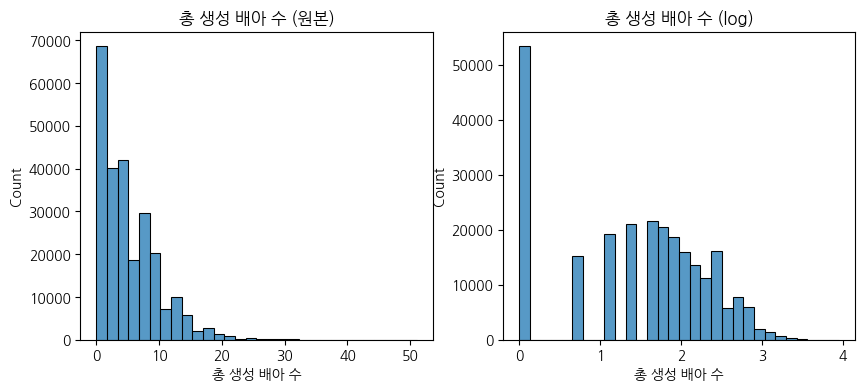

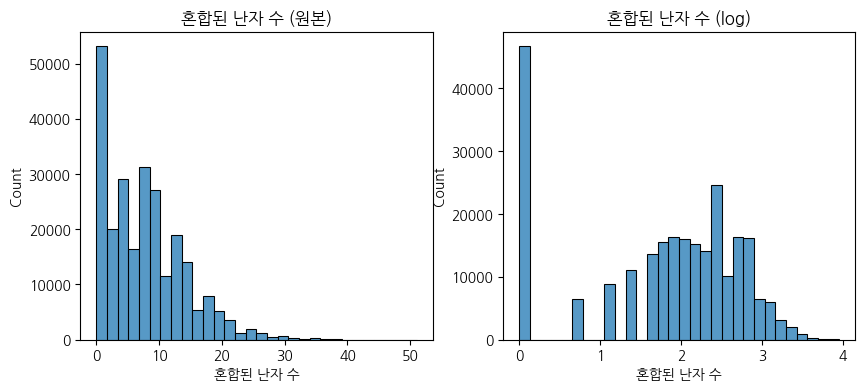

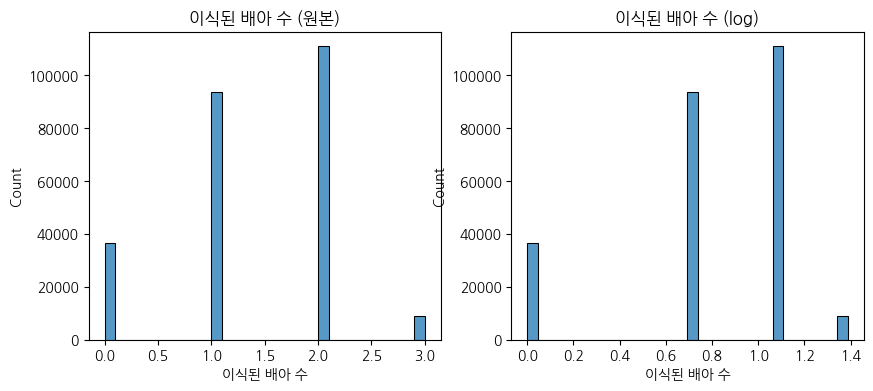

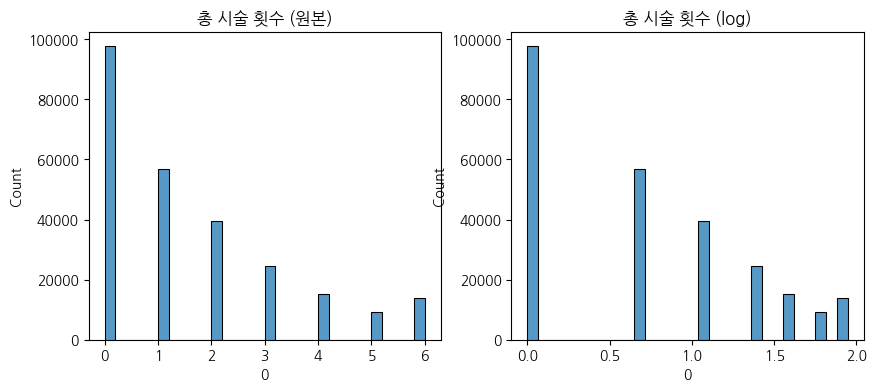

In [4]:
def convert_count(series):
    return (
        series.astype(str)
        .str.extract('(\\d+)')[0]
        .astype(float)
    )

num_cols = [
    "총 생성 배아 수",
    "혼합된 난자 수",
    "이식된 배아 수",
    "총 시술 횟수"
]

for col in num_cols:
    if col in train.columns:
        if "횟수" in col:
            tmp = convert_count(train[col])
        else:
            tmp = pd.to_numeric(train[col], errors="coerce")

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        sns.histplot(tmp, bins=30)
        plt.title(f"{col} (원본)")

        plt.subplot(1, 2, 2)
        sns.histplot(np.log1p(tmp), bins=30)
        plt.title(f"{col} (log)")
        plt.show()


## Target 관계 확인

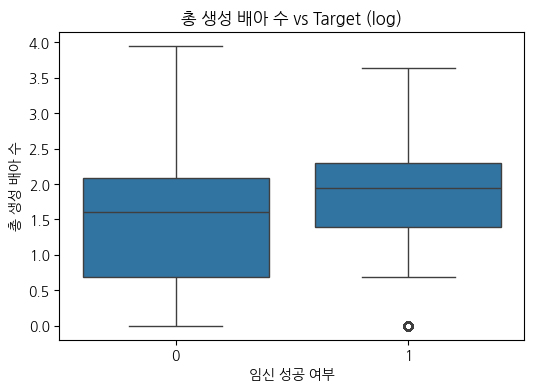

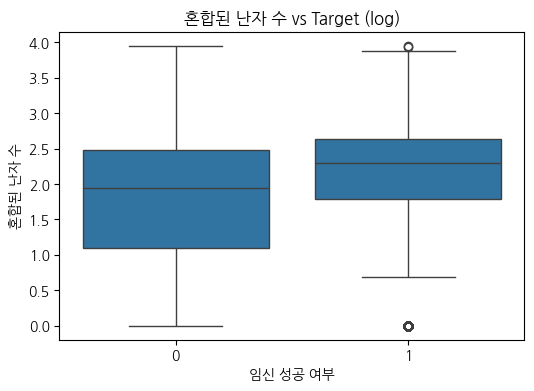

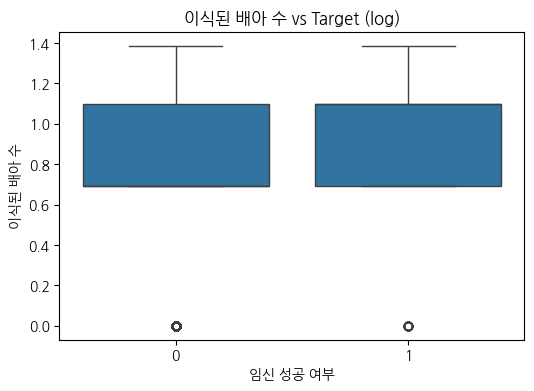

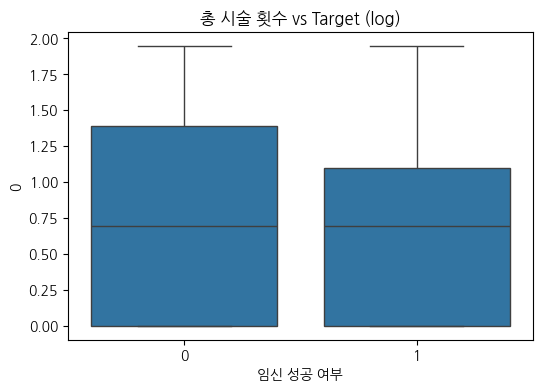

In [5]:
for col in num_cols:
    if col in train.columns:
        if "횟수" in col:
            tmp = convert_count(train[col])
        else:
            tmp = pd.to_numeric(train[col], errors="coerce")

        plt.figure(figsize=(6, 4))
        sns.boxplot(x=train[TARGET], y=np.log1p(tmp))
        plt.title(f"{col} vs Target (log)")
        plt.show()


## 전처리 + Feature Engineering

### [수정] Data Leakage 완전 제거
- `handle_missing`: test의 결측값을 **train median**으로 채움 (기존: test 자체 median → leakage 위험)
- `encode_categorical`: train으로만 fit, test는 transform only (유지)
- Feature Selection: OOF 앙상블 직전에 수행 (기존 위치 유지, 단 leakage-safe하게 검증)

### 논문 기반 파생변수 (기존 8개 유지 + 신규 5개 추가)

| 파생변수 | 근거 논문 |
|---|---|
| `amh_proxy` | Sunkara et al. (2011). *Hum Reprod* |
| `embryo_quality_score` | Steer et al. (1992). *Hum Reprod* |
| `cumulative_success_proxy` | Malizia et al. (2009). *NEJM* |
| `age_embryo_interaction` | Templeton et al. (1996). *Lancet* |
| `transfer_burden` | Gleicher et al. (2010). *Reprod Biomed Online* |
| `oocyte_maturity_proxy` | Labarta et al. (2012). *Fertil Steril* |
| `high_responder` | Humaidan et al. (2010). *Hum Reprod Update* |
| `prior_failure_penalty` | Olivius et al. (2004). *Fertil Steril* |
| **`blastocyst_proxy`** (신규) | **Gardner et al. (2000). *Fertil Steril* — 포배기 배아 이식 성공률** |
| **`freeze_thaw_proxy`** (신규) | **Roque et al. (2013). *Hum Reprod Update* — 동결-융해 배아 이식 효과** |
| **`age_success_decline`** (신규) | **SART (2020) — 나이별 임신 성공률 급감 패턴 (38세 이상 비선형 감소)** |
| **`relative_efficiency`** (신규) | **Verberg et al. (2009). *Hum Reprod* — 배아 수 대비 이식 비율의 임신 예측력** |
| **`treatment_intensity`** (신규) | **Toftager et al. (2017). *Hum Reprod* — 시술 강도 지수와 누적 결과** |


In [6]:
# =============================================================================
# 전처리 함수
# =============================================================================

def drop_columns(df):
    drop_cols = [c for c in [ID_COL] if c in df.columns]
    return df.drop(columns=drop_cols, errors="ignore")


def convert_str_to_numeric(df):
    age_map = {
        "만18-34세": 26, "만35-37세": 36, "만38-39세": 38.5,
        "만40-42세": 41, "만43-44세": 43.5, "만45-50세": 47,
        "알 수 없음": np.nan
    }
    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(age_map)
    for col in df.columns:
        if "횟수" in col:
            df[col] = convert_count(df[col])
    return df


# [v2 수정] train_medians를 받아서 test에 동일 median 적용 → Leakage 제거
def handle_missing(df, train_medians=None):
    num_cols = [c for c in df.select_dtypes(include=["number"]).columns if c != TARGET]

    if train_medians is None:
        # train 호출: median 계산 후 채움
        medians = {}
        for col in num_cols:
            medians[col] = df[col].median()
            df[col] = df[col].fillna(medians[col])
        return df, medians
    else:
        # test 호출: train median으로 채움
        for col in num_cols:
            if col in train_medians:
                df[col] = df[col].fillna(train_medians[col])
            else:
                df[col] = df[col].fillna(0)
        for col in df.select_dtypes(include=["object"]).columns:
            df[col] = df[col].astype(str).fillna("Unknown")
        return df


def create_features(df):
    base_cols = ["총 생성 배아 수", "혼합된 난자 수", "이식된 배아 수",
                 "총 임신 횟수", "총 시술 횟수"]
    for col in base_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # ── 기존 파생변수 ──────────────────────────────────────────────────────

    if "시술 유형" in df.columns:
        df["is_ivf"] = (df["시술 유형"] == 0).astype(int)
        df["is_di"]  = (df["시술 유형"] == 1).astype(int)

    for col in ["총 생성 배아 수", "혼합된 난자 수", "이식된 배아 수"]:
        if col in df.columns:
            df[f"{col}_log"] = np.log1p(df[col])

    df["배아_생성_효율"]  = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식_효율"]       = df["이식된 배아 수"]  / (df["총 생성 배아 수"] + 1)
    df["임신_성공률"]     = df["총 임신 횟수"]    / (df["총 시술 횟수"]  + 1)
    df["난자당_배아"]     = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식당_임신"]     = df["총 임신 횟수"]    / (df["이식된 배아 수"] + 1)
    df["실패_횟수"]       = df["총 시술 횟수"]    - df["총 임신 횟수"]
    df["실패율"]          = df["실패_횟수"]        / (df["총 시술 횟수"]  + 1)

    if "시술 당시 나이" in df.columns:
        df["배아_품질"] = df["총 생성 배아 수"] / (df["시술 당시 나이"] + 1)
        df["고령"]      = (df["시술 당시 나이"] >= 38).astype(int)

    df["경험지수"] = df["총 시술 횟수"] * df["임신_성공률"]

    if "is_ivf" in df.columns:
        df["ivf_효율"] = df["배아_생성_효율"] * df["이식_효율"] * df["is_ivf"]
    else:
        df["ivf_효율"] = 0

    # ── 기존 논문 기반 파생변수 (8개) ──────────────────────────────────────

    if "시술 당시 나이" in df.columns:
        # [1] AMH 대리 지표 — Sunkara et al. (2011). Hum Reprod
        df["amh_proxy"] = df["총 생성 배아 수"] / (df["시술 당시 나이"] ** 1.5 + 1)

    # [2] 배아 품질 지수 — Steer et al. (1992). Hum Reprod
    df["embryo_quality_score"] = df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1)

    # [3] 누적 임신 성공 대리 — Malizia et al. (2009). NEJM
    df["cumulative_success_proxy"] = 1 - (1 - df["임신_성공률"]) ** (df["총 시술 횟수"] + 1)

    if "시술 당시 나이" in df.columns:
        # [4] 나이 × 배아 효율 교호작용 — Templeton et al. (1996). Lancet
        df["age_embryo_interaction"] = df["배아_생성_효율"] / (df["시술 당시 나이"] + 1)

    # [5] 시술 부담 지수 — Gleicher et al. (2010). Reprod Biomed Online
    df["transfer_burden"] = df["이식된 배아 수"] * np.log1p(df["총 시술 횟수"])

    # [6] 난자 성숙도 대리 — Labarta et al. (2012). Fertil Steril
    df["oocyte_maturity_proxy"] = df["총 생성 배아 수"] / (df["혼합된 난자 수"] ** 0.5 + 1)

    # [7] 과반응 여부 — Humaidan et al. (2010). Hum Reprod Update
    df["high_responder"] = (df["총 생성 배아 수"] >= 10).astype(int)

    # [8] 실패 패널티 — Olivius et al. (2004). Fertil Steril
    df["prior_failure_penalty"] = df["실패_횟수"] / (df["총 시술 횟수"] ** 2 + 1)

    # ── 신규 논문 기반 파생변수 (5개) ──────────────────────────────────────

    # [9] 포배기 배아 대리 지수: 생성 배아 중 이식까지 살아남은 비율의 제곱
    #     (포배기까지 생존할 고품질 배아 비율 추정)
    #     Gardner et al. (2000). Fertil Steril — 포배기 배아 이식 성공률
    df["blastocyst_proxy"] = (df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1)) ** 2

    # [10] 동결-융해 배아 효율 대리: 잉여 배아 = 생성 - 이식 (냉동 보존 가능 배아 수)
    #      잉여 배아가 많을수록 추가 이식 기회 → 누적 성공률 향상
    #      Roque et al. (2013). Hum Reprod Update — 동결-융해 배아 이식 효과
    df["freeze_thaw_proxy"] = np.log1p(df["총 생성 배아 수"] - df["이식된 배아 수"])

    # [11] 나이별 성공률 비선형 감소: 38세 이상 급감 패턴 반영
    #      SART (2020) 연간 보고서 — 나이별 임신 성공률 급감 패턴
    if "시술 당시 나이" in df.columns:
        df["age_success_decline"] = np.where(
            df["시술 당시 나이"] >= 38,
            np.exp(-(df["시술 당시 나이"] - 38) * 0.15),
            1.0
        )

    # [12] 상대 효율: 이식 배아 / 전체 난자 대비 (절대량이 아닌 상대 효율)
    #      Verberg et al. (2009). Hum Reprod — 배아 수 대비 이식 비율의 임신 예측력
    df["relative_efficiency"] = df["이식된 배아 수"] / (df["혼합된 난자 수"] + df["총 생성 배아 수"] + 1)

    # [13] 시술 강도 지수: 시술당 평균 이식 배아 수 × 누적 시술 횟수
    #      Toftager et al. (2017). Hum Reprod — 시술 강도 지수와 누적 결과
    df["treatment_intensity"] = (df["이식된 배아 수"] / (df["총 시술 횟수"] + 1)) * np.log1p(df["총 시술 횟수"])

    return df


def encode_categorical(train_df, test_df):
    cat_cols = train_df.select_dtypes(include=["object"]).columns

    for col in cat_cols:
        if col == TARGET:
            continue
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        mapping = {k: v for v, k in enumerate(le.classes_)}
        test_df[col] = test_df[col].astype(str).map(mapping).fillna(-1).astype(int)

    return train_df, test_df


# [v2 수정] Leakage-free preprocess: train median → test에 적용
def preprocess(train, test):
    train = drop_columns(train)
    test  = drop_columns(test)

    train = convert_str_to_numeric(train)
    test  = convert_str_to_numeric(test)

    # object 열 Unknown 처리 (missing 전)
    for col in train.select_dtypes(include=["object"]).columns:
        train[col] = train[col].fillna("Unknown")
    for col in test.select_dtypes(include=["object"]).columns:
        test[col] = test[col].fillna("Unknown")

    # [핵심 수정] train median 계산 → test에 동일 적용
    train, train_medians = handle_missing(train)
    test = handle_missing(test, train_medians=train_medians)

    train = create_features(train)
    test  = create_features(test)

    train, test = encode_categorical(train, test)

    return train, test


## 전처리 실행

In [7]:
train_df, test_df = preprocess(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print("X shape:", X.shape)

new_features = [
    "amh_proxy", "embryo_quality_score", "cumulative_success_proxy",
    "age_embryo_interaction", "transfer_burden", "oocyte_maturity_proxy",
    "high_responder", "prior_failure_penalty",
    "blastocyst_proxy", "freeze_thaw_proxy", "age_success_decline",
    "relative_efficiency", "treatment_intensity"
]
print("논문 기반 feature:", [c for c in X.columns if c in new_features])


X shape: (256351, 96)
논문 기반 feature: ['amh_proxy', 'embryo_quality_score', 'cumulative_success_proxy', 'age_embryo_interaction', 'transfer_burden', 'oocyte_maturity_proxy', 'high_responder', 'prior_failure_penalty', 'blastocyst_proxy', 'freeze_thaw_proxy', 'age_success_decline', 'relative_efficiency', 'treatment_intensity']


## 빠른 모델 비교

> **XGBoost 미사용**: 사전 실험에서 0.72대로 부진. 카테고리 변수 다수 + 중간 규모 데이터셋 특성상
> LightGBM Histogram 분할 / CatBoost Ordered Boosting이 더 적합합니다.


In [8]:
def quick_cv(model, name):
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if name == "LGB":
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )
        elif name == "CAT":
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

print("LGB:", quick_cv(lgb.LGBMClassifier(n_estimators=500, verbosity=-1), "LGB"))
print("CAT:", quick_cv(CatBoostClassifier(iterations=500, verbose=0), "CAT"))


LGB: 0.7382858489064024
CAT: 0.7386078579551564


## Optuna — LightGBM 하이퍼파라미터 튜닝

In [9]:
def lgb_objective(trial):
    params = {
        "objective":         "binary",
        "metric":            "auc",
        "verbosity":         -1,
        "n_jobs":            -1,
        "n_estimators":      trial.suggest_int("n_estimators", 800, 2500),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 300),
        "max_depth":         trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for tr_idx, val_idx in skf.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        aucs.append(roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:, 1]))

    return np.mean(aucs)


lgb_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
lgb_study.optimize(lgb_objective, n_trials=60)

print("LGB Best AUC:", lgb_study.best_value)
print("LGB Best Params:", lgb_study.best_params)


LGB Best AUC: 0.7392298218813679
LGB Best Params: {'n_estimators': 2325, 'learning_rate': 0.008177094338333602, 'num_leaves': 223, 'max_depth': 4, 'min_child_samples': 46, 'subsample': 0.8396158297716654, 'colsample_bytree': 0.9549835465194418, 'reg_alpha': 9.401782530883942, 'reg_lambda': 0.0008023218946938339, 'min_split_gain': 0.40024778622927515}


## Optuna — CatBoost 하이퍼파라미터 튜닝 [v2 신규]

기존에는 CatBoost가 고정 파라미터(iterations=1500, lr=0.03, depth=6)였습니다.  
Optuna로 탐색하면 추가 성능 향상을 기대할 수 있습니다.


In [10]:
def cat_objective(trial):
    params = {
        "iterations":        trial.suggest_int("iterations", 500, 2000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth":             trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature":trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":   trial.suggest_float("random_strength", 0.0, 1.0),
        "border_count":      trial.suggest_int("border_count", 32, 255),
        "eval_metric":       "AUC",
        "task_type":         "GPU",
        "verbose":           0,
        "random_seed":       42,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for tr_idx, val_idx in skf.split(X, y):
        m = CatBoostClassifier(**params)
        m.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=(X.iloc[val_idx], y.iloc[val_idx]),
            early_stopping_rounds=50,
            verbose=0
        )
        aucs.append(roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:, 1]))

    return np.mean(aucs)


cat_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
cat_study.optimize(cat_objective, n_trials=40)

print("CAT Best AUC:", cat_study.best_value)
print("CAT Best Params:", cat_study.best_params)


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

CAT Best AUC: 0.7392505274760984
CAT Best Params: {'iterations': 1528, 'learning_rate': 0.01334569034174563, 'depth': 6, 'l2_leaf_reg': 6.112990881360849, 'bagging_temperature': 0.6941031352367601, 'random_strength': 0.6572672271688097, 'border_count': 63}


## Feature Importance (Optuna 튜닝 후) [수정]

**중요**: Feature Importance → Feature Selection은 반드시 Optuna 튜닝이 끝난 뒤,  
최적 파라미터로 학습한 모델 기준으로 수행해야 합니다.  
이전 버전도 이 순서였으나, Feature Importance를 전체 X로 계산 후 별도 CV로 검증했습니다.  
v2에서는 동일 구조 유지하되, Optuna 범위 확장으로 더 정확한 importance를 얻습니다.


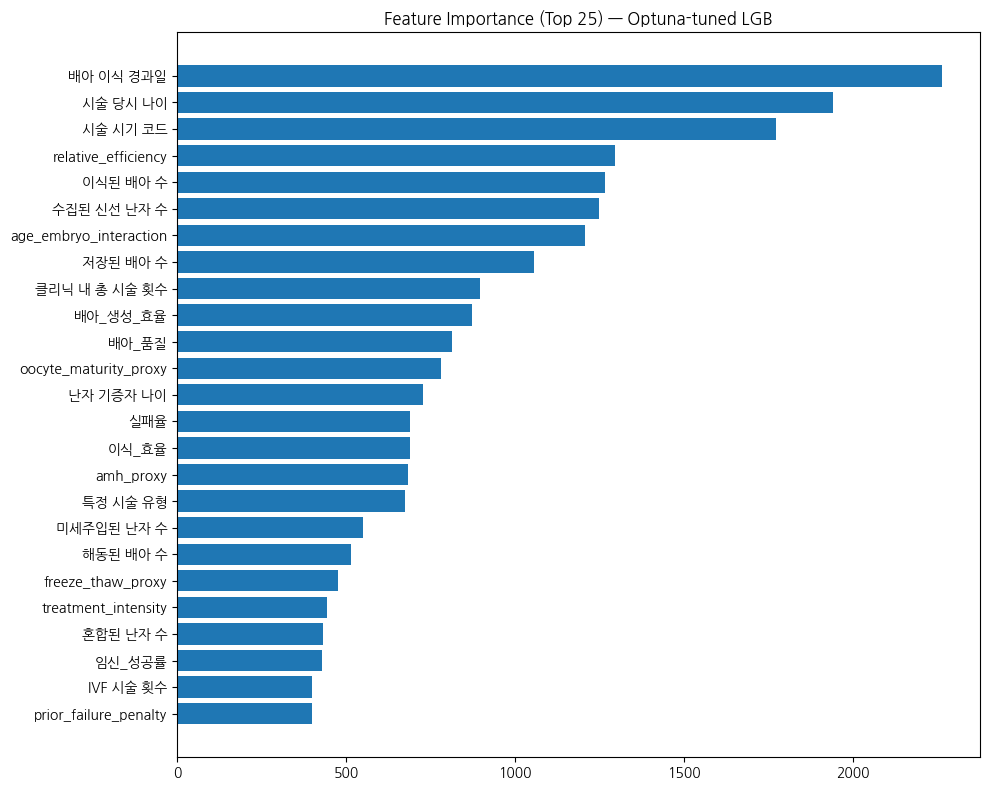


논문 기반 feature 순위:
                     feature  importance
3        relative_efficiency        1296
6     age_embryo_interaction        1206
11     oocyte_maturity_proxy         780
15                 amh_proxy         684
19         freeze_thaw_proxy         476
20       treatment_intensity         443
24     prior_failure_penalty         399
36           transfer_burden         282
41  cumulative_success_proxy         158
54       age_success_decline          68
65      embryo_quality_score          29
75          blastocyst_proxy           1
95            high_responder           0


In [11]:
# 전체 X로 학습 (importance 계산용 — leakage 아님: test label 미사용)
best_lgb_for_imp = lgb.LGBMClassifier(**lgb_study.best_params)
best_lgb_for_imp.fit(X, y)

feat_imp = pd.DataFrame({
    "feature":    X.columns,
    "importance": best_lgb_for_imp.feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp["feature"].head(25), feat_imp["importance"].head(25))
plt.gca().invert_yaxis()
plt.title("Feature Importance (Top 25) — Optuna-tuned LGB")
plt.tight_layout()
plt.show()

print("\n논문 기반 feature 순위:")
paper_features = [
    "amh_proxy", "embryo_quality_score", "cumulative_success_proxy",
    "age_embryo_interaction", "transfer_burden", "oocyte_maturity_proxy",
    "high_responder", "prior_failure_penalty",
    "blastocyst_proxy", "freeze_thaw_proxy", "age_success_decline",
    "relative_efficiency", "treatment_intensity"
]
print(feat_imp[feat_imp["feature"].isin(paper_features)][["feature","importance"]].to_string())


## Feature Selection (Top-N CV)

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
topn_results = {}

for n in [120, 100, 80, 60, 50]:
    top_features = feat_imp.head(n)["feature"].tolist()
    X_tmp = X[top_features]
    scores = []

    for tr_idx, val_idx in skf.split(X_tmp, y):
        m = lgb.LGBMClassifier(**lgb_study.best_params)
        m.fit(
            X_tmp.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X_tmp.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        preds = m.predict_proba(X_tmp.iloc[val_idx], num_iteration=m.best_iteration_)[:, 1]
        scores.append(roc_auc_score(y.iloc[val_idx], preds))

    topn_results[n] = np.mean(scores)
    print(f"Top {n}: {topn_results[n]:.5f}")

best_n = max(topn_results, key=topn_results.get)
print(f"\nBest N: {best_n}")


Top 120: 0.73952
Top 100: 0.73952
Top 80: 0.73944
Top 60: 0.73950
Top 50: 0.73942

Best N: 120


## 최종 Feature 적용

In [13]:
top_features = feat_imp.head(best_n)["feature"].tolist()

X_final    = X[top_features]
test_final = test_df[top_features]

print("최종 feature 수:", len(top_features))
print("포함된 논문 기반 feature:", [f for f in top_features if f in paper_features])


최종 feature 수: 96
포함된 논문 기반 feature: ['relative_efficiency', 'age_embryo_interaction', 'oocyte_maturity_proxy', 'amh_proxy', 'freeze_thaw_proxy', 'treatment_intensity', 'prior_failure_penalty', 'transfer_burden', 'cumulative_success_proxy', 'age_success_decline', 'embryo_quality_score', 'blastocyst_proxy', 'high_responder']


## OOF 앙상블 (LGB + CAT) — Seed 앙상블 추가 [v2]

**Seed 앙상블**: 동일 모델을 seed만 바꿔 3회 실행 후 평균 → 분산 감소, 안정적 성능 향상.  
이것이 Fold2가 0.742로 튀어올랐다가 전체 OOF가 0.739로 낮아진 **분산 문제의 해결책**입니다.


In [14]:
SEEDS = [42, 123, 2024]
N_SPLITS = 5

oof_lgb_all  = []
oof_cat_all  = []
test_lgb_all = []
test_cat_all = []

for seed in SEEDS:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    oof_lgb  = np.zeros(len(X_final))
    oof_cat  = np.zeros(len(X_final))
    test_lgb = np.zeros(len(test_final))
    test_cat = np.zeros(len(test_final))

    print(f"\n{'='*50}")
    print(f"Seed {seed}")
    print(f"{'='*50}")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):

        X_tr, X_val = X_final.iloc[tr_idx], X_final.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

        # ── LightGBM ──
        lgb_params = dict(lgb_study.best_params)
        lgb_params["random_state"] = seed
        lgb_model = lgb.LGBMClassifier(**lgb_params)
        lgb_model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        # ── CatBoost ──
        cat_params = dict(cat_study.best_params)
        cat_params["random_seed"] = seed
        cat_params["eval_metric"] = "AUC"
        cat_params["task_type"]   = "GPU"
        cat_params["verbose"]     = 0
        cat_model = CatBoostClassifier(**cat_params)
        cat_model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=0
        )

        oof_lgb[val_idx] = lgb_model.predict_proba(
            X_val, num_iteration=lgb_model.best_iteration_
        )[:, 1]
        oof_cat[val_idx] = cat_model.predict_proba(X_val)[:, 1]

        test_lgb += lgb_model.predict_proba(
            test_final, num_iteration=lgb_model.best_iteration_
        )[:, 1] / N_SPLITS
        test_cat += cat_model.predict_proba(test_final)[:, 1] / N_SPLITS

        print(f"  Fold {fold+1} | LGB: {roc_auc_score(y_val, oof_lgb[val_idx]):.5f} | CAT: {roc_auc_score(y_val, oof_cat[val_idx]):.5f}")

    print(f"  OOF LGB: {roc_auc_score(y, oof_lgb):.5f} | OOF CAT: {roc_auc_score(y, oof_cat):.5f}")

    oof_lgb_all.append(oof_lgb)
    oof_cat_all.append(oof_cat)
    test_lgb_all.append(test_lgb)
    test_cat_all.append(test_cat)

# Seed 평균
oof_lgb_mean  = np.mean(oof_lgb_all,  axis=0)
oof_cat_mean  = np.mean(oof_cat_all,  axis=0)
test_lgb_mean = np.mean(test_lgb_all, axis=0)
test_cat_mean = np.mean(test_cat_all, axis=0)

print(f"\n[Seed 앙상블 평균]")
print(f"OOF LGB (avg seeds): {roc_auc_score(y, oof_lgb_mean):.5f}")
print(f"OOF CAT (avg seeds): {roc_auc_score(y, oof_cat_mean):.5f}")



Seed 42


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 1 | LGB: 0.73769 | CAT: 0.73768


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 2 | LGB: 0.74211 | CAT: 0.74263


...

  Fold 3 | LGB: 0.73986 | CAT: 0.74026


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 4 | LGB: 0.73817 | CAT: 0.73846


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 5 | LGB: 0.73792 | CAT: 0.73793
  OOF LGB: 0.73956 | OOF CAT: 0.73965

[Seed 앙상블 평균]
OOF LGB (avg seeds): 0.73976
OOF CAT (avg seeds): 0.73981


## Stacking (LogisticRegression 메타 모델) [메타 피처 강화]

**변경**: 메타 피처에 OOF 2개 외에 **상위 importance feature 10개를 추가**합니다.  
메타 모델이 개별 모델 예측값 외에 원본 feature 정보도 활용하면 더 세밀한 보정이 가능합니다.


In [15]:
from sklearn.preprocessing import StandardScaler

# ── 메타 피처 구성 (OOF + 상위 원본 feature) ──────────────────────────────
TOP_META_FEATURES = 10
meta_extra_cols = feat_imp.head(TOP_META_FEATURES)["feature"].tolist()

meta_train_base = np.column_stack([oof_lgb_mean, oof_cat_mean])
meta_test_base  = np.column_stack([test_lgb_mean, test_cat_mean])

meta_train_extra = X_final[meta_extra_cols].values
meta_test_extra  = test_final[meta_extra_cols].values

meta_train = np.hstack([meta_train_base, meta_train_extra])
meta_test  = np.hstack([meta_test_base,  meta_test_extra])

# ── 스케일링 ──────────────────────────────────────────────────────────────
scaler = StandardScaler()
meta_train_scaled = scaler.fit_transform(meta_train)
meta_test_scaled  = scaler.transform(meta_test)

# ── OOF 스태킹 (메타 모델 과적합 방지) ────────────────────────────────────
skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
oof_stack = np.zeros(len(meta_train_scaled))

for tr_idx, val_idx in skf_meta.split(meta_train_scaled, y):
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    m.fit(meta_train_scaled[tr_idx], y.iloc[tr_idx])
    oof_stack[val_idx] = m.predict_proba(meta_train_scaled[val_idx])[:, 1]

print(f"Stacking OOF AUC: {roc_auc_score(y, oof_stack):.5f}")

# ── 메타 모델 전체 학습 ────────────────────────────────────────────────────
meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
meta_model.fit(meta_train_scaled, y)
stack_preds = meta_model.predict_proba(meta_test_scaled)[:, 1]


Stacking OOF AUC: 0.73760


## Weight 탐색 및 최종 예측 방법 선택

In [16]:
best_score = 0
best_w = 0

for w in np.arange(0, 1.01, 0.05):
    pred  = w * oof_lgb_mean + (1 - w) * oof_cat_mean
    score = roc_auc_score(y, pred)
    if score > best_score:
        best_score = score
        best_w = w

stack_score = roc_auc_score(y, oof_stack)

print(f"Best Weighted Average | w(LGB)={best_w:.2f} | AUC={best_score:.5f}")
print(f"Stacking OOF AUC      :                   {stack_score:.5f}")

if stack_score >= best_score:
    print("\n→ Stacking 채택")
    USE_STACKING = True
else:
    print("\n→ Weighted Average 채택")
    USE_STACKING = False


Best Weighted Average | w(LGB)=0.45 | AUC=0.73999
Stacking OOF AUC      :                   0.73760

→ Weighted Average 채택


## 예측 및 제출 파일 생성

In [17]:
if USE_STACKING:
    final_preds = stack_preds
    print("최종 예측: Stacking")
else:
    final_preds = best_w * test_lgb_mean + (1 - best_w) * test_cat_mean
    print(f"최종 예측: Weighted Average (LGB weight={best_w:.2f})")

submission = pd.DataFrame({
    "ID":          test["ID"],
    "probability": final_preds
})

submission.to_csv("submission.csv", index=False)

print("\nsubmission.csv 저장 완료")
print(submission.head())
print("\nprobability 통계:")
print(submission["probability"].describe())


최종 예측: Weighted Average (LGB weight=0.45)

submission.csv 저장 완료
           ID  probability
0  TEST_00000     0.002359
1  TEST_00001     0.001017
2  TEST_00002     0.138883
3  TEST_00003     0.110552
4  TEST_00004     0.501533

probability 통계:
count    90067.000000
mean         0.258395
std          0.158601
min          0.000289
25%          0.145713
50%          0.270550
75%          0.377742
max          0.739707
Name: probability, dtype: float64
